In [1]:
import pandas as pd

flight = pd.read_csv("s3://flight-delay-ml-group12/T_ONTIME_REPORTING.csv")
weather = pd.read_csv("s3://flight-delay-ml-group12/noaa_weather_2024_final.csv")

print(flight.shape)
print(weather.shape)
flight.head()
weather.head()

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/fsspec/registry.py:301: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


(547271, 22)
(3648, 12)


,STATION,DATE,AIRPORT,Wind Speed,Air Temperature,Atmospheric Pressure,Daily Visibility,Dew Point Temperature,Daily Precipitation,Cloud Cover,Max Wind Gust Speed,Daily Snowfall Depth
0,72219013874,2024/1/1,ATL,7.8,44.7,1020.2,10.0,31.3,0.00,0,22.9,NaN
1,72219013874,2024/1/2,ATL,7.2,39.3,1024.6,10.0,24.9,0.00,0,22.0,NaN
2,72219013874,2024/1/3,ATL,4.4,39.4,1020.7,9.9,27.4,0.00,10000,NaN,NaN
3,72219013874,2024/1/4,ATL,8.1,41.2,1019.9,10.0,30.8,0.03,0,19.0,NaN
4,72219013874,2024/1/5,ATL,8.0,40.5,1023.7,10.0,26.3,0.00,0,15.9,NaN


In [2]:
weather = weather.rename(columns={
    'Wind Speed': 'WIND_SPEED',
    'Air Temperature': 'AIR_TEMPERATURE',
    'Atmospheric Pressure': 'PRESSURE',
    'Daily Visibility': 'VISIBILITY',
    'Dew Point Temperature': 'DEW_POINT',
    'Daily Precipitation': 'PRECIPITATION',
    'Cloud Cover': 'CLOUD_COVER',
    'Max Wind Gust Speed': 'WIND_GUST',
    'Daily Snowfall Depth': 'SNOW_DEPTH'
})

In [3]:
#flight feature
flight_features = [
    'MONTH',
    'DAY_OF_MONTH',
    'DAY_OF_WEEK',
    'CRS_DEP_TIME',   # planned departure time
    'CRS_ARR_TIME',   # planned arrival time
    'DISTANCE',
    'ORIGIN',
    'DEST',
    'OP_UNIQUE_CARRIER'
]

In [4]:
#weather feature
weather_features = [
    'Wind Speed',
    'Air Temperature',
    'Daily Visibility',
    'Daily Precipitation',
    'Cloud Cover',
    'Max Wind Gust Speed',
    'Daily Snow Depth'
]

In [5]:
# delete cancelled flight
flight = flight[flight['CANCELLED'] == 0]
# label
flight['delay'] = (flight['ARR_DELAY'] >= 15).astype(int)

In [6]:
#delete leakage features
leakage_cols = [
    'ARR_DELAY',
    'CARRIER_DELAY',
    'WEATHER_DELAY',
    'NAS_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'DEP_DELAY', 
    'TAXI_OUT'
]
flight = flight.drop(columns=leakage_cols, errors='ignore')

In [7]:
# transform date columns to datetime
flight['FL_DATE'] = pd.to_datetime(flight['FL_DATE'])
weather['DATE'] = pd.to_datetime(weather['DATE'])

# merge
df = flight.merge(
    weather,
    left_on=['ORIGIN', 'FL_DATE'],
    right_on=['AIRPORT', 'DATE'],
    how='left'
)

/tmp/ipykernel_8640/1918052675.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  flight['FL_DATE'] = pd.to_datetime(flight['FL_DATE'])


In [8]:
df = df.sample(50000, random_state=42)

In [9]:
df = df.dropna(subset=['WIND_SPEED'])

In [10]:
df.head()
df.isna().sum()

YEAR                     0
MONTH                    0
DAY_OF_MONTH             0
DAY_OF_WEEK              0
FL_DATE                  0
OP_UNIQUE_CARRIER        0
TAIL_NUM                 0
ORIGIN                   0
DEST                     0
CRS_DEP_TIME             0
CRS_ARR_TIME             0
CANCELLED                0
CRS_ELAPSED_TIME         0
DISTANCE                 0
SECURITY_DELAY       11903
delay                    0
STATION                  0
DATE                     0
AIRPORT                  0
WIND_SPEED               0
AIR_TEMPERATURE          0
PRESSURE                 0
VISIBILITY               0
DEW_POINT                0
PRECIPITATION            0
CLOUD_COVER              0
WIND_GUST             7569
SNOW_DEPTH           13625
dtype: int64

In [11]:
df[['SECURITY_DELAY', 'WIND_GUST', 'SNOW_DEPTH']] = \
df[['SECURITY_DELAY', 'WIND_GUST', 'SNOW_DEPTH']].fillna(0)

In [12]:
#categorical encoding
top_origins = df['ORIGIN'].value_counts().nlargest(10).index
df['ORIGIN'] = df['ORIGIN'].where(df['ORIGIN'].isin(top_origins), 'OTHER')

df = pd.get_dummies(df, columns=['ORIGIN'], drop_first=True)

In [13]:
#prepare data
X = df.drop(columns=['delay'])
y = df['delay']

X = X.select_dtypes(include=['number'])

In [14]:
#split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
#model
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier()
model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [23]:
model_columns = X_train.columns
import joblib

joblib.dump(model_columns, "columns.pkl")

['columns.pkl']

In [24]:
#metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


y_prob = model.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.3).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7463399108847868
Precision: 0.46504992867332384
Recall: 0.4358288770053476
F1: 0.4499654934437543
AUC: 0.7131224898252764


In [25]:
df['delay'].value_counts(normalize=True)

delay
0    0.757863
1    0.242137
Name: proportion, dtype: float64

In [26]:
df['hour'] = df['CRS_DEP_TIME'] // 100
df.groupby('hour')['delay'].mean()

hour
0     0.148148
1     0.000000
5     0.139303
6     0.117455
7     0.169975
8     0.220541
9     0.212177
10    0.243902
11    0.256086
12    0.226460
13    0.265326
14    0.272727
15    0.247350
16    0.258581
17    0.298097
18    0.271058
19    0.315206
20    0.295060
21    0.208589
22    0.224900
23    0.194805
Name: delay, dtype: float64

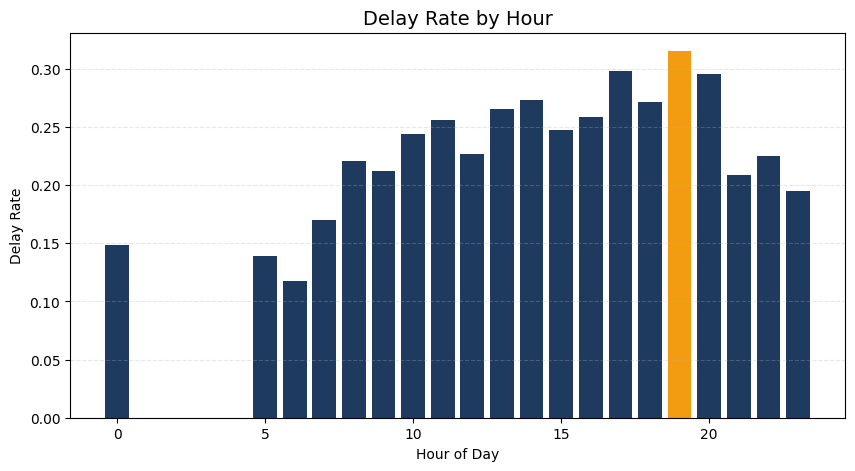

In [27]:
import matplotlib.pyplot as plt
import numpy as np

delay_by_hour = df.groupby('hour')['delay'].mean()

colors = ['#1F3A5F'] * len(delay_by_hour)


max_idx = np.argmax(delay_by_hour.values)
colors[max_idx] = '#F39C12'  

plt.figure(figsize=(10,5))

plt.bar(delay_by_hour.index, delay_by_hour.values, color=colors)

plt.title('Delay Rate by Hour', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Delay Rate')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [28]:
import joblib
joblib.dump(model, "model.pkl")

['model.pkl']

In [30]:
import joblib
import pandas as pd

# load model & columns
model = joblib.load("model.pkl")
cols = joblib.load("columns.pkl")


sample_input = pd.DataFrame({
    "MONTH": [1],
    "DAY_OF_MONTH": [15],
    "DAY_OF_WEEK": [3],
    "CRS_DEP_TIME": [1400],
    "CRS_ARR_TIME": [1600],
    "DISTANCE": [800]
})

# ⚠️ 核心：dummy + 对齐
sample_input = pd.get_dummies(sample_input)
sample_input = sample_input.reindex(columns=cols, fill_value=0)

# 预测
pred_prob = model.predict_proba(sample_input)[0][1]

print("Delay Probability:", pred_prob)

Delay Probability: 0.8629651058870016
